We will discuss here how can we connect a Tool and an LLM and also How an LLM calls a Tool when it is needed.

## Tool Binding

Tool Binding is the process where you connect your tool with the LLM.

Tool Binding is the process where you register tools with a LLM so that:
1. The LLM knows what tools are available
2. It knows what each tool does (via description)
3. It knows what input format to use (via schema)

In [3]:
from langchain_core.prompts import PromptTemplate
import requests
import os
from dotenv import load_dotenv
from langchain.tools import tool
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
load_dotenv()

True

In [9]:
@tool
def multiply(a:int,b:int)->int:
    ''' Given two numbers a and b. This tool returns their product'''
    return a*b


print(multiply.invoke({'a':5,'b':6}))
print(multiply.name)
print(multiply.args)
print(multiply.description)

30
multiply
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}
Given two numbers a and b. This tool returns their product


In [12]:
## Tool Binding

## model.bind_tools(list of tools you send )
llm=HuggingFaceEndpoint(
    task='text-generation',
    repo_id='Qwen/Qwen3-4B-Instruct-2507'
)

model_with_tools=ChatHuggingFace(llm=llm).bind_tools([multiply])

## Note:
Not every LLM has the capability to bind a tool with it. There are only few LLMs that have this ability

## Tool Calling

Tool Calling is the process where the LLM decides, during a conversation or a task, that it needs to use a specific tool (function).

To call the tool, LLM generates a structured output with:
- Name of the tool
- Arguments to call the tool

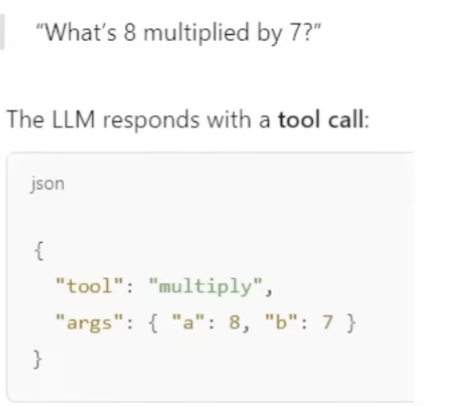

## Note: 
LLM does not actually run the tool. It just suggests the tool and the input argument. The actual execution of the tool is handled by LangChain or you 

In [13]:
model_with_tools.invoke('Hi How are you')

AIMessage(content="I'm just a text-based AI, so I don't have feelings. But thanks for asking! How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 167, 'total_tokens': 195}, 'model_name': 'Qwen/Qwen3-4B-Instruct-2507', 'system_fingerprint': 'vllm-0.21.0-233fc06d', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01d63-2e3a-7e40-a3ec-04df646d02b3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 167, 'output_tokens': 28, 'total_tokens': 195})

In [18]:
result=model_with_tools.invoke('What is 80 multiply with 40')

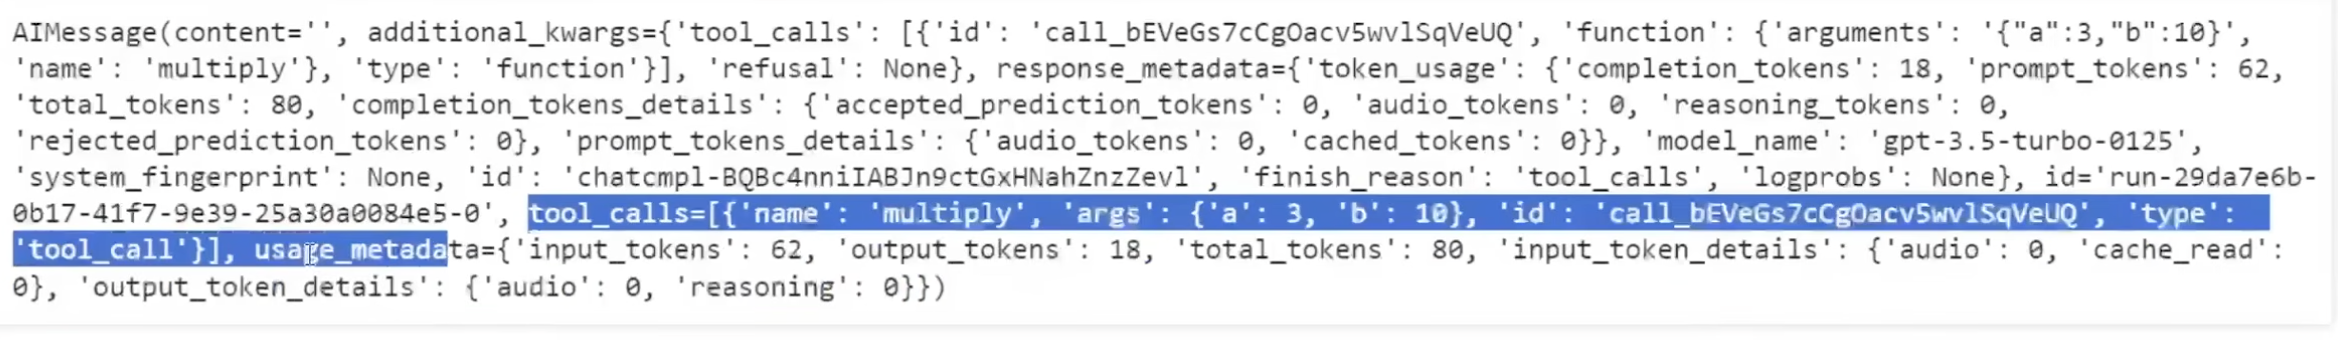

In [23]:
result.tool_calls[0]

## There is unique id for every tool call

{'name': 'multiply',
 'args': {'a': 80, 'b': 40},
 'id': 'chatcmpl-tool-b0f38a2e0ce1ad80',
 'type': 'tool_call'}

We thought LLM will invoke this tool and we will get result. This is not correct, LLM never executes a tool, it could only suggest that we can use this tool and these are the arguments you can pass

LLM could just give you an advice that you can use this tool

In [24]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"a": 80, "b": 40}', 'name': 'multiply', 'description': None}, 'id': 'chatcmpl-tool-b0f38a2e0ce1ad80', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 173, 'total_tokens': 200}, 'model_name': 'Qwen/Qwen3-4B-Instruct-2507', 'system_fingerprint': 'vllm-0.21.0-233fc06d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01d67-c9a6-7ca0-9718-f70483aff099-0', tool_calls=[{'name': 'multiply', 'args': {'a': 80, 'b': 40}, 'id': 'chatcmpl-tool-b0f38a2e0ce1ad80', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 173, 'output_tokens': 27, 'total_tokens': 200})

# Tool Execution

Tool Execution is the step where the actual python function (tool) is run using the input arguments that the LLM suggested during tool calling.

In simpler words:

The LLM says: "Hey, Call the multiply tool with a=8 and b=7". 

Tool Execution is when you or langchain actually run: multiply(a=8,a=7) and get the result:56

In [28]:
result=model_with_tools.invoke('Can you multiply 3 with 10').tool_calls[0]
result

{'name': 'multiply',
 'args': {'a': 3, 'b': 10},
 'id': 'chatcmpl-tool-b64e82ad729a0ee5',
 'type': 'tool_call'}

In [30]:
var=result['args']
multiply.invoke(var)

30

In [34]:
multiply.invoke({
 'name': 'multiply',
 'args': {'a': 3, 'b': 10},
 'id': 'chatcmpl-tool-b64e82ad729a0ee5',
 'type': 'tool_call'}
 )
## We get ToolMessage

## ToolMessage is a special kind of message you get when you execute a tool with the help of a tool call

ToolMessage(content='30', name='multiply', tool_call_id='chatcmpl-tool-b64e82ad729a0ee5')

In [35]:
multiply.invoke(result)

ToolMessage(content='30', name='multiply', tool_call_id='chatcmpl-tool-b64e82ad729a0ee5')

## Complete Flow

In [2]:

from langchain_core.prompts import PromptTemplate
import requests
import os
from dotenv import load_dotenv
from langchain.tools import tool
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
load_dotenv()

True

In [22]:
## Tool Creation
@tool
def multiply(a:int,b:int)->int:
    ''' Given two numbers a and b. This tool returns their product'''
    return a*b

## Tool Binding
llm=HuggingFaceEndpoint(
    task='text-generation',
    repo_id='Qwen/Qwen3-4B-Instruct-2507'
)
model_with_tools=ChatHuggingFace(llm=llm).bind_tools([multiply])
query=HumanMessage('Can you multiply 3 with 16')
messages=[query]
result=model_with_tools.invoke(messages)
messages.append(result)
messages

[HumanMessage(content='Can you multiply 3 with 16', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"a": 3, "b": 16}', 'name': 'multiply', 'description': None}, 'id': 'chatcmpl-tool-97d8020a9daae663', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 172, 'total_tokens': 198}, 'model_name': 'Qwen/Qwen3-4B-Instruct-2507', 'system_fingerprint': 'vllm-0.21.0-233fc06d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01d90-6bdf-7631-85e3-08332968f120-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 16}, 'id': 'chatcmpl-tool-97d8020a9daae663', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 172, 'output_tokens': 26, 'total_tokens': 198})]

In [23]:
tool_result=multiply.invoke(result.tool_calls[0])
tool_result

ToolMessage(content='48', name='multiply', tool_call_id='chatcmpl-tool-97d8020a9daae663')

In [24]:
messages.append(tool_result)

In [25]:
messages

[HumanMessage(content='Can you multiply 3 with 16', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"a": 3, "b": 16}', 'name': 'multiply', 'description': None}, 'id': 'chatcmpl-tool-97d8020a9daae663', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 172, 'total_tokens': 198}, 'model_name': 'Qwen/Qwen3-4B-Instruct-2507', 'system_fingerprint': 'vllm-0.21.0-233fc06d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01d90-6bdf-7631-85e3-08332968f120-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 16}, 'id': 'chatcmpl-tool-97d8020a9daae663', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 172, 'output_tokens': 26, 'total_tokens': 198}),
 ToolMessage(content='48', name='multiply', tool_call_id='chatcmpl-tool-97d8020a9daae663')]

In [26]:
model_with_tools.invoke(messages).content

'The product of 3 and 16 is 48.'

## Currency conversion Tool

We need real time answer

like right now price of dollar is 90 as of now. Don't have to use historical data. We want real time answer and conversion factor


We will create a tool which is python function, inside that function we will hit api 

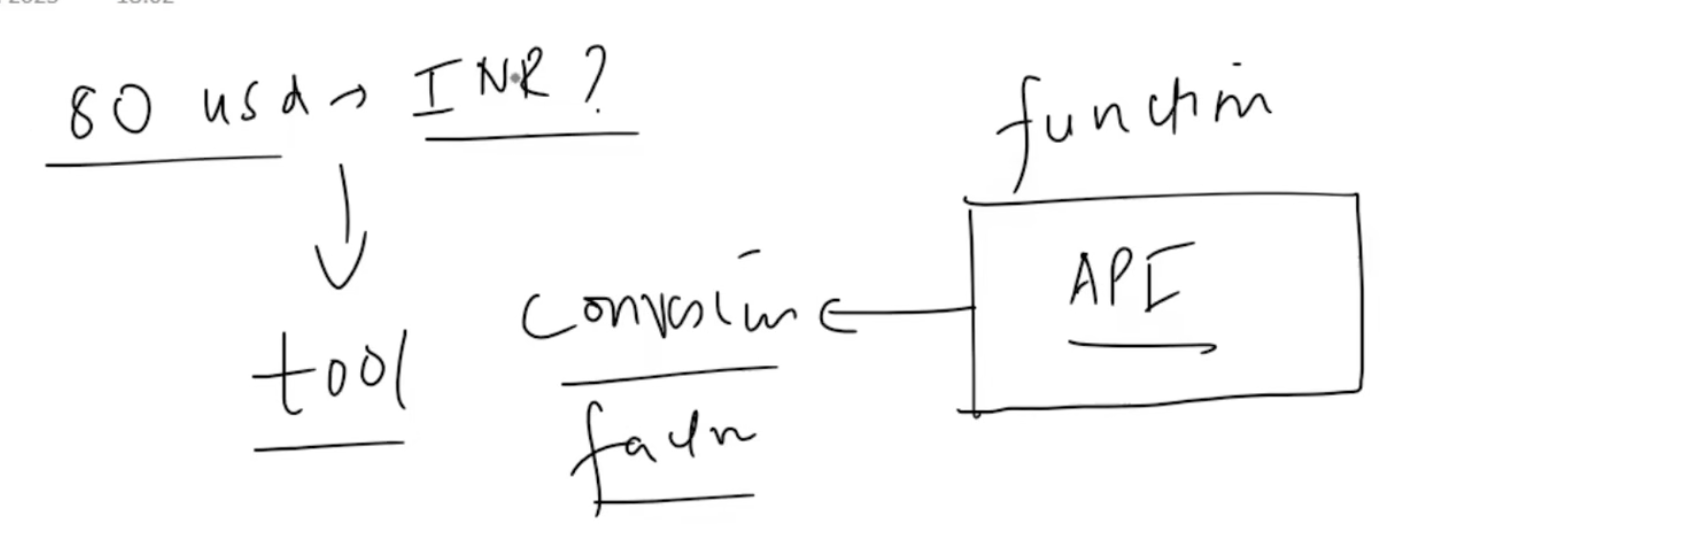

## Tools

Tool No 1 - Hits API and gives currency exchange factor

Tool No 2 - Multiplies with the factor and gives answer

In [27]:

from langchain_core.prompts import PromptTemplate
import requests
import os
from dotenv import load_dotenv
from langchain.tools import tool
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
load_dotenv()

True

In [97]:
from langchain_core.tools import InjectedToolArg 
from typing import Annotated

In [37]:
url=f'https://v6.exchangerate-api.com/v6/410c8246609edbdbb31897ac/latest/USD'
response=requests.get(url)
response.json()

{'result': 'success',
 'documentation': 'https://www.exchangerate-api.com/docs',
 'terms_of_use': 'https://www.exchangerate-api.com/terms',
 'time_last_update_unix': 1787184001,
 'time_last_update_utc': 'Thu, 20 Aug 2026 00:00:01 +0000',
 'time_next_update_unix': 1787270401,
 'time_next_update_utc': 'Fri, 21 Aug 2026 00:00:01 +0000',
 'base_code': 'USD',
 'conversion_rates': {'USD': 1,
  'AED': 3.6725,
  'AFN': 65.2464,
  'ALL': 79.9301,
  'AMD': 364.5849,
  'ANG': 1.79,
  'AOA': 923.562,
  'ARS': 1497.5332,
  'AUD': 1.4072,
  'AWG': 1.79,
  'AZN': 1.7002,
  'BAM': 1.6787,
  'BBD': 2.0,
  'BDT': 122.1981,
  'BGN': 1.6787,
  'BHD': 0.376,
  'BIF': 2991.0029,
  'BMD': 1.0,
  'BND': 1.2736,
  'BOB': 11.5619,
  'BRL': 5.1908,
  'BSD': 1.0,
  'BTN': 95.75,
  'BWP': 13.6964,
  'BYN': 3.0377,
  'BZD': 2.0,
  'CAD': 1.3826,
  'CDF': 2292.663,
  'CHF': 0.8031,
  'CLF': 0.02345,
  'CLP': 927.0286,
  'CNH': 6.7327,
  'CNY': 6.7461,
  'COP': 3099.309,
  'CRC': 448.1543,
  'CUP': 24.0,
  'CVE': 94.

In [44]:
response.json()['conversion_rates']

{'USD': 1,
 'AED': 3.6725,
 'AFN': 65.2464,
 'ALL': 79.9301,
 'AMD': 364.5849,
 'ANG': 1.79,
 'AOA': 923.562,
 'ARS': 1497.5332,
 'AUD': 1.4072,
 'AWG': 1.79,
 'AZN': 1.7002,
 'BAM': 1.6787,
 'BBD': 2.0,
 'BDT': 122.1981,
 'BGN': 1.6787,
 'BHD': 0.376,
 'BIF': 2991.0029,
 'BMD': 1.0,
 'BND': 1.2736,
 'BOB': 11.5619,
 'BRL': 5.1908,
 'BSD': 1.0,
 'BTN': 95.75,
 'BWP': 13.6964,
 'BYN': 3.0377,
 'BZD': 2.0,
 'CAD': 1.3826,
 'CDF': 2292.663,
 'CHF': 0.8031,
 'CLF': 0.02345,
 'CLP': 927.0286,
 'CNH': 6.7327,
 'CNY': 6.7461,
 'COP': 3099.309,
 'CRC': 448.1543,
 'CUP': 24.0,
 'CVE': 94.6416,
 'CZK': 20.7611,
 'DJF': 177.721,
 'DKK': 6.4418,
 'DOP': 58.7379,
 'DZD': 132.9399,
 'EGP': 50.6789,
 'ERN': 15.0,
 'ETB': 161.3488,
 'EUR': 0.8584,
 'FJD': 2.2089,
 'FKP': 0.7357,
 'FOK': 6.4417,
 'GBP': 0.7359,
 'GEL': 2.6118,
 'GGP': 0.7357,
 'GHS': 11.0744,
 'GIP': 0.7357,
 'GMD': 74.7288,
 'GNF': 8780.5511,
 'GTQ': 7.6319,
 'GYD': 209.2004,
 'HKD': 7.8411,
 'HNL': 26.8228,
 'HRK': 6.4669,
 'HTG': 13

In [45]:
response.json()['conversion_rates']['INR']

95.7489

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
## Tool creation

## tool no-1

@tool
def get_conversion_factor(base_currency:str, target_currency:str)->float:
    """ This function fetches the currency conversion factor between a given base currency and a target currency"""
    url=f'https://v6.exchangerate-api.com/v6/410c8246609edbdbb31897ac/latest/{base_currency}'
    response=requests.get(url)
    return response.json()['conversion_rates'][target_currency]


## Tool no-2

@tool
def convert(base_currency_value:int, conversion_rate: Annotated[float,InjectedToolArg])->float:
## "conversion_rate: Annotated[float,InjectedToolArg]" means jab hamara llm is particular tool ko call karega toh woh conversion_rate khudse nahi bharega. 
## InjectedToolArg - LLM,do not try to fill this argument by yourself. I(the developer/runtime) will inject this value after running earlier tools
    '''Given a currency conversion rate, this function calculates the target currency value from a given base currency value'''
    return base_currency_value * conversion_rate


## Tool Binding
model_with_tools=model.bind_tools([convert,get_conversion_factor])

In [68]:
query=HumanMessage(content='convert 10 USD to INR ?')
messages=[query]
response=model_with_tools.invoke(messages)
messages.append(response)
response

AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_conversion_factor', 'arguments': '{"base_currency": "USD", "target_currency": "INR"}'}, '__gemini_function_call_thought_signatures__': {'call_1165223': 'EpoECpcEARFNMg/dF7SI4SvwLW3VCdyaRhxJ2Yh4wstSEX5DTcIdh6kQcQ4dkc8quUu6urbDGaL9/VdTpia2OQs4lByo+gmjj2vWK+50tQVy0Fm3pnTx8fHWwsDkrPs4EdJKhAxXy9AsdEMaVhP3ALioIh8lmsTsN+Du8+L9pbe79BcR0ETn7s6M06Clt0nFSOs9Zm/7BltVwc1kNAu5HMW10Sk0Gg3gYGLFAir4GONMySyCg9jJGzR10abhAkQlrUQcLoo2Qjx29mHYCiU0U8QwGWxsMZsLNz7mE9jYBktM0AQNKazu1l80wvuwZt06tWFrAk5A3Zntq9KdRjOirUrGSFGqzjkZNlk1GvBemlE/MfUHDOiriQdzMQecNyFr38jrZNSq7eqGkHw5H5qfwwaMgU2cV4DtmHyDx3i9lasA+7xSD1v8VHctOwwAuaG7RTx+GoMTqCSTSht1gmf88JgPvfywgjKGY5mdgJeizGUOxJW1zPzG9+L+HZr1z2L1XOQUdUPxeI5Ypj0O7mkKAiua26/4z/knQEDEFITSK5TWzReSUGBxv35N4l4EmAaWyXc1xTPrQlc8HmLs+2FrQ5GYw1dt3nYJuapnjdQB6i+wL8Ko8AfD8S/DEzXldyYipG+kYmMZz1y06n8lqRxUo0HCJZHLv+ZpqgFIfzn/IDkF532j4+RyKLtT507GOM9MEBbuzJqy5u64SinMbA=='}}, response_metadata={'finish_reason': 'STOP', 'm

In [82]:
result=response.tool_calls[0]
result

{'name': 'get_conversion_factor',
 'args': {'base_currency': 'USD', 'target_currency': 'INR'},
 'id': 'call_1165223',
 'type': 'tool_call'}

In [88]:
tool_message=get_conversion_factor.invoke(result)
messages.append(tool_message)
tool_message

ToolMessage(content='95.7489', name='get_conversion_factor', tool_call_id='call_1165223')

In [89]:
response=model_with_tools.invoke(messages)
response

AIMessage(content=[], additional_kwargs={'function_call': {'name': 'convert', 'arguments': '{"conversion_rate": 95.7489, "base_currency_value": 10}'}, '__gemini_function_call_thought_signatures__': {'call_1183214': 'EucCCuQCARFNMg9qy2NHq94zntNFB4dZfLM3Y0OAZSgP3IcMXl/Pr9sUxowp1Ppvwv/XjNbsyw0LhJfNtEln5N19WOnbNGeUOAWhp8JG8XuREeJAvelLZi5f1igquBjOX0bWlA3k2egYEzqS5HfGQaOFMamPd9yiG2JvppJti4am52bVUFxfsY+BR4gS2pwVx3zzxiG1zlL22oKj46PkFfEeJxocw2OcvPYAHLSJWJu0lAIyyk2TlGOAadm4BIOqrXk38MvPMz9p4aOl2W3f9h72Cj1goBFEYTUhm6CkREIYAvPhp6E16fuwFYyP+7yy+II64LURwWrxLyyLy1BsZAZ90/WMXj8/gpjS/fIShAaeDeppp8SltIB+hSbcM9/25L2a9l/Vs+kz8sMkYhChX06XenQMirNja3XuDQEanh6Ur8+wSYc8s2vW4sgWzTzPvJo/oe63f/TcJ4ChZRxoVZKkZCjM+jG++OI='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.6-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a01dbd-9c76-76c3-a933-c3563e18b7f6-0', tool_calls=[{'name': 'convert', 'args': {'conversion_rate': 95.7489, 'base_currency_value': 10}, 'id': 'cal

In [91]:
messages.append(response)
mess=response.tool_calls[0]
mess

{'name': 'convert',
 'args': {'conversion_rate': 95.7489, 'base_currency_value': 10},
 'id': 'call_1183214',
 'type': 'tool_call'}

In [93]:
tool_message=convert.invoke(mess)
messages.append(tool_message)

In [94]:
response=model_with_tools.invoke(messages)
response

AIMessage(content=[{'type': 'text', 'text': '10 USD is equal to approximately **957.49 INR** (at an exchange rate of 1 USD = 95.7489 INR).', 'extras': {'signature': 'EsQBCsEBARFNMg87t31t1CARUSp8qJu980GOjfIbdkW3loOIeUeVkKhagYWD5OH7cKx/tscQtwfQIuGZ6Ts6rIiwiozd5mWIbdGc4/mb+0+ew72KhiAJjfbzplYv42/7fJIA7jlauKIa3ZURkZqDI5tOzmeA1akr+actPrm0W8QEl7NVtnAKm1ZTZRQb5mTbfCb+DkuVZJg3jc/YwFjGh2Abqa3e0gegr+nGEaHJ37HU2MfEcn708sXoRfeSFUV+3NFqaK3KRA=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.6-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a01dbf-8a06-7c12-914e-bbb7a7c6bd04-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 440, 'output_tokens': 62, 'total_tokens': 502, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 26}})

In [95]:
messages.append(response)
messages

[HumanMessage(content='convert 10 USD to INR ?', additional_kwargs={}, response_metadata={}),
 AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_conversion_factor', 'arguments': '{"base_currency": "USD", "target_currency": "INR"}'}, '__gemini_function_call_thought_signatures__': {'call_1165223': 'EpoECpcEARFNMg/dF7SI4SvwLW3VCdyaRhxJ2Yh4wstSEX5DTcIdh6kQcQ4dkc8quUu6urbDGaL9/VdTpia2OQs4lByo+gmjj2vWK+50tQVy0Fm3pnTx8fHWwsDkrPs4EdJKhAxXy9AsdEMaVhP3ALioIh8lmsTsN+Du8+L9pbe79BcR0ETn7s6M06Clt0nFSOs9Zm/7BltVwc1kNAu5HMW10Sk0Gg3gYGLFAir4GONMySyCg9jJGzR10abhAkQlrUQcLoo2Qjx29mHYCiU0U8QwGWxsMZsLNz7mE9jYBktM0AQNKazu1l80wvuwZt06tWFrAk5A3Zntq9KdRjOirUrGSFGqzjkZNlk1GvBemlE/MfUHDOiriQdzMQecNyFr38jrZNSq7eqGkHw5H5qfwwaMgU2cV4DtmHyDx3i9lasA+7xSD1v8VHctOwwAuaG7RTx+GoMTqCSTSht1gmf88JgPvfywgjKGY5mdgJeizGUOxJW1zPzG9+L+HZr1z2L1XOQUdUPxeI5Ypj0O7mkKAiua26/4z/knQEDEFITSK5TWzReSUGBxv35N4l4EmAaWyXc1xTPrQlc8HmLs+2FrQ5GYw1dt3nYJuapnjdQB6i+wL8Ko8AfD8S/DEzXldyYipG+kYmMZz1y06n8lqRxUo0HCJZHLv+ZpqgFIfzn/

## Is this AI Agent application?

No, because:

- AI agent is autonomous, it automatically breaks down the problem and solves it step by step and doesn't require any help in between. 

- We did many of code and decision making by our own

## This is how Agent would have worked

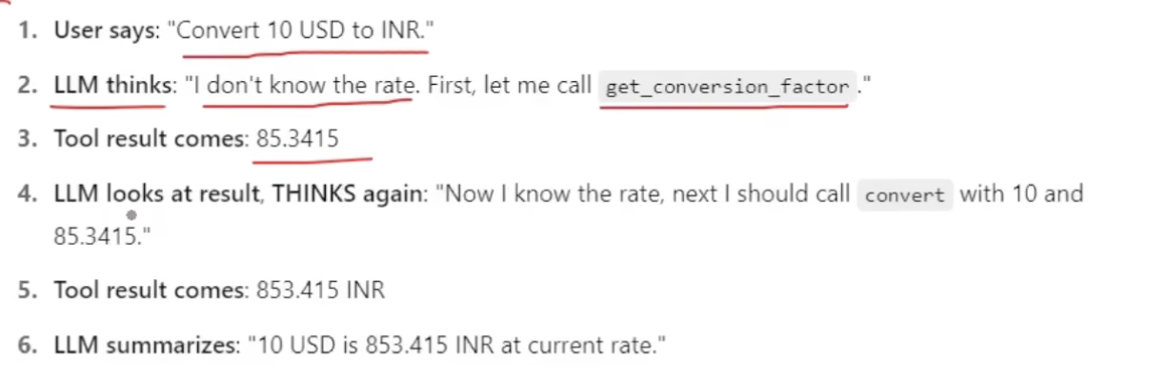